# 实践实验 - 应用机器学习的建议
在本实验中，你将探索评估和改进机器学习模型的技术。

# 大纲 
- [1 - 包 ](#1)
- [2 - 评估学习算法（多项式回归）](#2)
    - [2.1 拆分数据集](#2.1)
    - [2.2 模型评估的误差计算，线性回归](#2.2)
      - [练习1](#ex01)
    - [2.3 比较训练数据和测试数据的性能](#2.3)
- [3 - 偏差与方差<img align="Right" src="./images/C2_W3_BiasVarianceDegree.png"  style=" width:500px; padding: 10px 20px ; "> ](#3)
    - [3.1 绘制训练集、交叉验证集、测试集图表](#3.1)
    - [3.2 寻找最优次数](#3.2)
    - [3.3 调整正则化。](#3.3)
    - [3.4 获取更多数据：增加训练集大小（m）](#3.4)
- [4 - 评估学习算法（神经网络）](#4)
    - [4.1 数据集](#4.1)
    - [4.2 通过计算分类误差评估分类模型](#4.2)
        - [练习2](#ex02)
- [5 - 模型复杂度](#5)
    - [练习3](#ex03)
    - [5.1 简单模型](#5.1)
      - [练习4](#ex04)
- [6 - 正则化](#6)
    - [练习5](#ex05)
- [7 - 迭代寻找最优正则化值](#7)
    - [7.1 测试](#7.1)


<a name="1"></a>
## 1 - 软件包
首先，让我们运行下面的代码块，导入本次作业中所需的所有软件包。
- [numpy](https://numpy.org/) 是Python科学计算的基础软件包。
- [matplotlib](http://matplotlib.org) 是Python中常用的绘图库。
- [scikitlearn](https://scikit-learn.org/stable/) 是数据挖掘的基础库。
- [tensorflow](https://www.tensorflow.org/) 是流行的机器学习平台。

In [1]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from keras.activations import relu,linear
from keras.losses import SparseCategoricalCrossentropy
from keras.optimizers import Adam

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)

from public_tests_a1 import * 

tf.keras.backend.set_floatx('float64')
from assigment_utils import *

tf.autograph.set_verbosity(0)

<a name="2"></a>

## 2 - 评估学习算法（多项式回归）
<img align="Right" src="./images/C2_W3_TrainingVsNew.png"  style=" width:350px; padding: 10px 20px ; "> 假设你已经创建了一个机器学习模型，并且发现它与你的训练数据拟合得非常好。这就完成了吗？还没有。创建模型的目的是能够对<span style="color:blue">**新**</span>样本进行值预测。   
   
在部署模型之前，如何在新数据上测试模型的性能呢？   
答案分为两部分：   
* 将原始数据集拆分为“训练集”和“测试集”。
    * 使用训练数据来拟合模型的参数
    * 使用测试数据在**新**数据上评估模型
* 开发一个误差函数来评估你的模型。 

<a name="2.1"></a>
### 2.1 分割数据集
课程建议预留20%-40%的数据集用于测试。我们使用`sklearn`库中的[train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)函数来进行分割。运行以下代码块后，请仔细检查数据的形状。 

In [2]:
# Generate some data
X,y,x_ideal,y_ideal = gen_data(18, 2, 0.7)
print("X.shape", X.shape, "y.shape", y.shape)

#split the data using sklearn routine 
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.33, random_state=1)
print("X_train.shape", X_train.shape, "y_train.shape", y_train.shape)
print("X_test.shape", X_test.shape, "y_test.shape", y_test.shape)

X.shape (18,) y.shape (18,)
X_train.shape (12,) y_train.shape (12,)
X_test.shape (6,) y_test.shape (6,)


#### 2.1.1 绘制训练集和测试集
如下所示，你可以看到将作为训练数据的点（红色）与模型未用于训练的数据点（测试数据）相互交错。这个特定的数据集是一个添加了噪声的二次函数。图中还给出了 “理想” 曲线以供参考。 

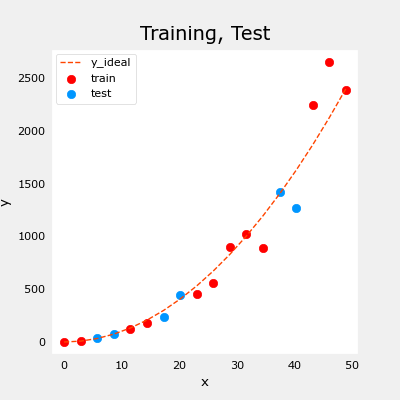

In [3]:
fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.plot(x_ideal, y_ideal, "--", color = "orangered", label="y_ideal", lw=1)
ax.set_title("Training, Test",fontsize = 14)
ax.set_xlabel("x")
ax.set_ylabel("y")

ax.scatter(X_train, y_train, color = "red",           label="train")
ax.scatter(X_test, y_test,   color = dlc["dlblue"],   label="test")
ax.legend(loc='upper left')
plt.show()

<a name="2.2"></a>
### 2.2 模型评估的误差计算，线性回归
在*评估*线性回归模型时，需计算预测值与目标值之间误差平方的平均值。

$$ J_\text{test}(\mathbf{w},b) = 
            \frac{1}{2m_\text{test}}\sum_{i=0}^{m_\text{test}-1} ( f_{\mathbf{w},b}(\mathbf{x}^{(i)}_\text{test}) - y^{(i)}_\text{test} )^2 
            \tag{1}
$$

<a name="ex01"></a>
### 练习1
下面，创建一个函数来评估线性回归模型在数据集上的误差。

In [4]:
# UNQ_C1
# GRADED CELL: eval_mse
def eval_mse(y, yhat):
    """ 
    Calculate the mean squared error on a data set.
    Args:
      y    : (ndarray  Shape (m,) or (m,1))  target value of each example
      yhat : (ndarray  Shape (m,) or (m,1))  predicted value of each example
    Returns:
      err: (scalar)             
    """
    m = len(y)
    err = 0.0
    for i in range(m):
    ### START CODE HERE ### 
        err_i = (yhat[i] - y[i])**2
        err = err + err_i
    err = err/(2*m)
    ### END CODE HERE ### 
    
    return(err)

In [5]:
y_hat = np.array([2.4, 4.2])
y_tmp = np.array([2.3, 4.1])
eval_mse(y_hat, y_tmp)

# BEGIN UNIT TEST
test_eval_mse(eval_mse)   
# END UNIT TEST

 All tests passed.


<details>
  <summary><font size="3" color="darkgreen"><b>Click for hints</b></font></summary>

    
```python
def eval_mse(y, yhat):
    """ 
    Calculate the mean squared error on a data set.
    Args:
      y    : (ndarray  Shape (m,) or (m,1))  target value of each example
      yhat : (ndarray  Shape (m,) or (m,1))  predicted value of each example
    Returns:
      err: (scalar)             
    """
    m = len(y)
    err = 0.0
    for i in range(m):
        err_i  = ( (yhat[i] - y[i])**2 ) 
        err   += err_i                                                                
    err = err / (2*m)                    
    return(err)
``` 

<a name="2.3"></a>
### 2.3 比较训练数据和测试数据上的性能
我们来构建一个高次多项式模型以最小化训练误差。这将使用 `sklearn` 中的线性回归函数。如果您想查看详细信息，代码在导入的实用工具文件中。以下是具体步骤：
* 创建并拟合模型。（“拟合” 是训练或运行梯度下降的另一种说法）。
* 计算训练数据上的误差。
* 计算测试数据上的误差。

In [6]:
# create a model in sklearn, train on training data
degree = 10
lmodel = lin_model(degree)
lmodel.fit(X_train, y_train)

# predict on training data, find training error
yhat = lmodel.predict(X_train)
err_train = lmodel.mse(y_train, yhat)

# predict on test data, find error
yhat = lmodel.predict(X_test)
err_test = lmodel.mse(y_test, yhat)

训练集上计算出的误差明显小于测试集上的误差。

In [7]:
print(f"training err {err_train:0.2f}, test err {err_test:0.2f}")

training err 58.01, test err 171215.01


下面的图表说明了原因。该模型对训练数据的拟合效果非常好。为此，它创建了一个复杂的函数。测试数据并非训练数据的一部分，该模型在这些数据上的预测效果很差。这个模型可以被描述为：1）过拟合，2）方差高，3）泛化能力差。 

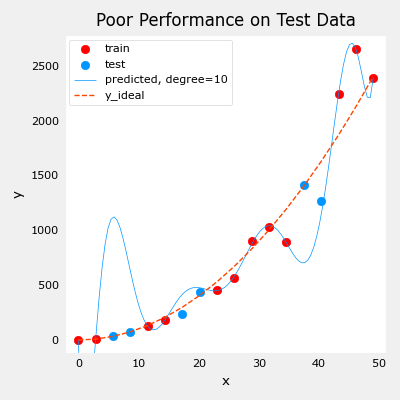

In [8]:
# 在数据范围内绘制预测结果
x = np.linspace(0,int(X.max()),100)   # 为绘图预测值     
y_pred = lmodel.predict(x).reshape(-1,1)

plt_train_test(X_train, y_train, X_test, y_test, x, y_pred, x_ideal, y_ideal, degree)

测试集误差表明，该模型在新数据上的表现不佳。如果你使用测试误差来指导模型的改进，那么模型在测试数据上会表现良好……但测试数据本应代表“新”数据。你还需要另一组数据来测试新数据的性能。

课堂上提出的建议是将数据分为三组。下表所示的训练集、交叉验证集和测试集的分布是一种典型分布，但也可以根据可用数据量进行调整。   

| 数据 | 占总数的百分比 | 描述 |
|------------------|:----------:|:---------|
| 训练集 | 60 | 用于在训练或拟合过程中调整模型参数$w$和$b$的数据 |
| 交叉验证集 | 20 | 用于调整其他模型参数（如多项式次数、正则化或神经网络架构）的数据 |
| 测试集 | 20 | 用于在调整模型后测试其在新数据上性能的数据 |

下面我们来生成三组数据。我们将再次使用`sklearn`库中的`train_test_split`函数，但要调用两次以得到三个分割数据集：

In [9]:
# Generate  data
X,y, x_ideal,y_ideal = gen_data(40, 5, 0.7)
print("X.shape", X.shape, "y.shape", y.shape)

#split the data using sklearn routine 
X_train, X_, y_train, y_ = train_test_split(X,y,test_size=0.40, random_state=1)
X_cv, X_test, y_cv, y_test = train_test_split(X_,y_,test_size=0.50, random_state=1)
print("X_train.shape", X_train.shape, "y_train.shape", y_train.shape)
print("X_cv.shape", X_cv.shape, "y_cv.shape", y_cv.shape)
print("X_test.shape", X_test.shape, "y_test.shape", y_test.shape)

X.shape (40,) y.shape (40,)
X_train.shape (24,) y_train.shape (24,)
X_cv.shape (8,) y_cv.shape (8,)
X_test.shape (8,) y_test.shape (8,)


<a name="3"></a>
## 3 - 偏差与方差<img align="Right" src="./images/C2_W3_BiasVarianceDegree.png"  style=" width:500px; padding: 10px 20px ; ">    
上面已经表明，多项式模型的次数过高。那么如何选择一个合适的值呢？事实证明，如图所示，训练集和交叉验证集的性能可以提供指导。通过尝试一系列的次数值，可以评估训练集和交叉验证集的性能。当次数变得过大时，相对于训练集的性能，交叉验证集的性能会开始下降。让我们在示例中尝试一下。

<a name="3.1"></a>
### 3.1 绘制训练集、交叉验证集、测试集
你可以在下方看到，属于训练集的数据点（红色）与模型未用于训练的数据点（测试集和交叉验证集）相互交错。 

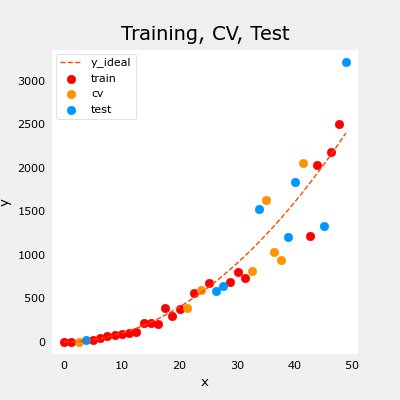

In [10]:
fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.plot(x_ideal, y_ideal, "--", color = "orangered", label="y_ideal", lw=1)
ax.set_title("Training, CV, Test",fontsize = 14)
ax.set_xlabel("x")
ax.set_ylabel("y")

ax.scatter(X_train, y_train, color = "red",           label="train")
ax.scatter(X_cv, y_cv,       color = dlc["dlorange"], label="cv")
ax.scatter(X_test, y_test,   color = dlc["dlblue"],   label="test")
ax.legend(loc='upper left')
plt.show()

<a name="3.2"></a>
### 3.2 寻找最优阶数
在之前的实验中，你已经发现可以通过使用多项式来创建一个能够拟合复杂曲线的模型（见课程1，第2周 特征工程与多项式回归实验）。此外，你还证明了通过增加多项式的*阶数*，可能会*导致*过拟合（见课程1，第3周 过拟合实验）。现在，我们利用这些知识来测试自己区分过拟合和欠拟合的能力。

我们将反复训练模型，每次迭代都增加多项式的阶数。在此，为了速度和简便性，我们将使用[scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression)线性回归模型。 

In [11]:
max_degree = 9
err_train = np.zeros(max_degree)    
err_cv = np.zeros(max_degree)      
x = np.linspace(0,int(X.max()),100)  
y_pred = np.zeros((100,max_degree))  #columns are lines to plot

for degree in range(max_degree):
    lmodel = lin_model(degree+1)
    lmodel.fit(X_train, y_train)
    yhat = lmodel.predict(X_train)
    err_train[degree] = lmodel.mse(y_train, yhat)
    yhat = lmodel.predict(X_cv)
    err_cv[degree] = lmodel.mse(y_cv, yhat)
    y_pred[:,degree] = lmodel.predict(x)
    
optimal_degree = np.argmin(err_cv)+1

<font size="4">让我们绘制结果：</font>

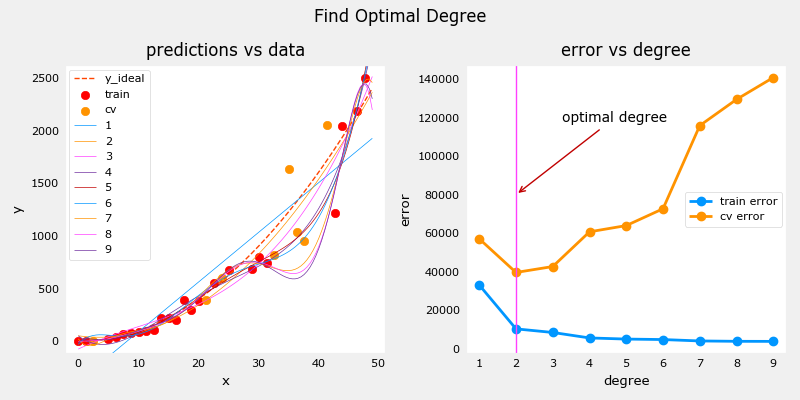

In [12]:
plt.close("all")
plt_optimal_degree(X_train, y_train, X_cv, y_cv, x, y_pred, x_ideal, y_ideal, 
                   err_train, err_cv, optimal_degree, max_degree)

上面的图表表明，将数据分为两组，即模型所训练的数据和模型未训练的数据，可用于判断模型是欠拟合还是过拟合。在我们的示例中，通过增加所使用多项式的次数，我们创建了从欠拟合到过拟合的各种模型。 
- 在左侧图表中，实线代表这些模型的预测结果。一次多项式模型生成的直线仅与极少数数据点相交，而最高次多项式模型则与每个数据点都极为贴近。
- 在右侧：
  - 如预期，随着模型复杂度的增加，训练数据的误差（蓝色）会降低
  - 交叉验证数据的误差在模型开始适应数据时最初会降低，但随着模型开始对训练数据过度拟合（无法实现*泛化*），误差会上升。

值得注意的是，这些示例中的曲线并不像在课堂上绘制的那样平滑。很明显，分配给每个组的具体数据点会显著改变结果。重要的是总体趋势。 

<a name="3.3"></a>
### 3.3 调整正则化。
在之前的实验中，你已经使用过**正则化**来减少过拟合。与调整多项式次数类似，人们可以使用相同的方法来调整正则化参数 lambda（$\lambda$）。  

我们从一个高次多项式开始并改变正则化参数，以此来进行演示。 

In [13]:
lambda_range = np.array([0.0, 1e-6, 1e-5, 1e-4,1e-3,1e-2, 1e-1,1,10,100])
num_steps = len(lambda_range)
degree = 10
err_train = np.zeros(num_steps)    
err_cv = np.zeros(num_steps)       
x = np.linspace(0,int(X.max()),100) 
y_pred = np.zeros((100,num_steps))  #columns are lines to plot

for i in range(num_steps):
    lambda_= lambda_range[i]
    lmodel = lin_model(degree, regularization=True, lambda_=lambda_)
    lmodel.fit(X_train, y_train)
    yhat = lmodel.predict(X_train)
    err_train[i] = lmodel.mse(y_train, yhat)
    yhat = lmodel.predict(X_cv)
    err_cv[i] = lmodel.mse(y_cv, yhat)
    y_pred[:,i] = lmodel.predict(x)
    
optimal_reg_idx = np.argmin(err_cv) 

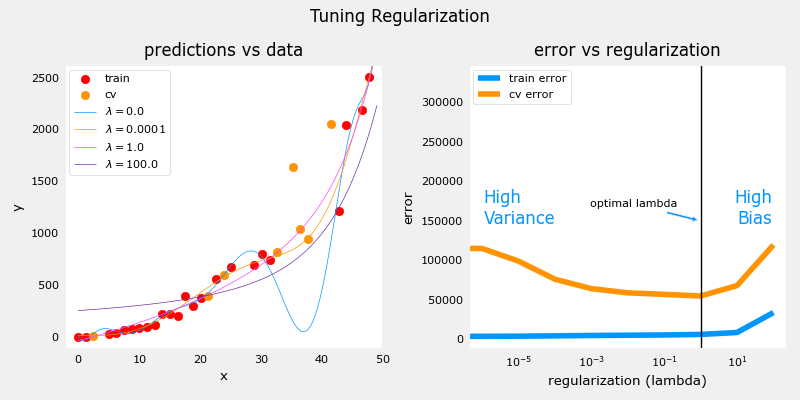

In [14]:
plt.close("all")
plt_tune_regularization(X_train, y_train, X_cv, y_cv, x, y_pred, err_train, err_cv, optimal_reg_idx, lambda_range)

上图展示了随着正则化程度的增加，模型从高方差（过拟合）模型转变为高偏差（欠拟合）模型。右图中的垂直线表示λ的最优值。在这个例子中，多项式次数被设置为10。 

<a name="3.4"></a>
### 3.4 获取更多数据：增加训练集规模（m）
当模型过拟合（高方差）时，收集更多数据可以提高性能。我们在这里试试。

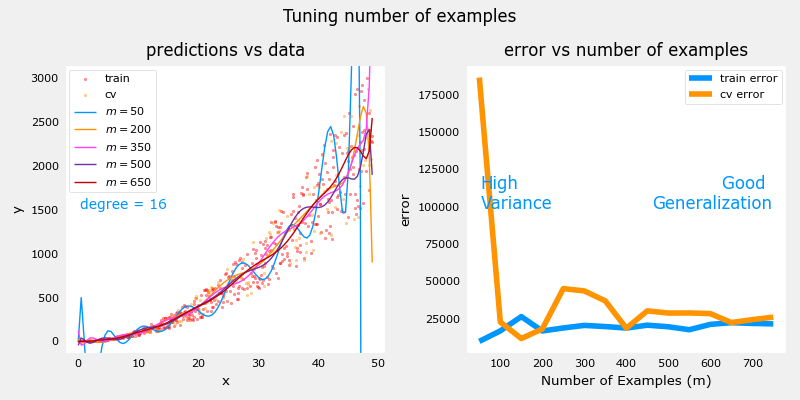

In [15]:
X_train, y_train, X_cv, y_cv, x, y_pred, err_train, err_cv, m_range,degree = tune_m()
plt_tune_m(X_train, y_train, X_cv, y_cv, x, y_pred, err_train, err_cv, m_range, degree)

上述图表表明，当模型方差较大且出现过拟合时，增加更多样本会提升性能。   
请注意左图中的曲线。$m$值最大的最后一条曲线是一条平滑曲线，位于数据的中心位置。   
在右图中，随着样本数量的增加，训练集和交叉验证集的性能收敛到相似的值。   
请注意，这些曲线并不像在课堂上看到的那么平滑，这是可以预料的。趋势仍然很明显：更多的数据能提升泛化能力。   

> 请注意，当模型偏差较大（欠拟合）时，增加更多样本并不能提升性能。 


<a name="4"></a>
## 4 - 评估学习算法（神经网络）
上述内容中，你调整了多项式回归模型的各个方面。在此，你将使用神经网络模型。我们先创建一个分类数据集。 

<a name="4.1"></a>
### 4.1 数据集
运行下面的代码块以生成一个数据集，并将其拆分为训练集、交叉验证（CV）集和测试集。在本示例中，为了突出显示，我们增加了交叉验证数据点的百分比。

In [16]:
# Generate and split data set
X, y, centers, classes, std = gen_blobs()

# split the data. Large CV population for demonstration
X_train, X_, y_train, y_ = train_test_split(X,y,test_size=0.50, random_state=1)
X_cv, X_test, y_cv, y_test = train_test_split(X_,y_,test_size=0.20, random_state=1)
print("X_train.shape:", X_train.shape, "X_cv.shape:", X_cv.shape, "X_test.shape:", X_test.shape)

X_train.shape: (400, 2) X_cv.shape: (320, 2) X_test.shape: (80, 2)


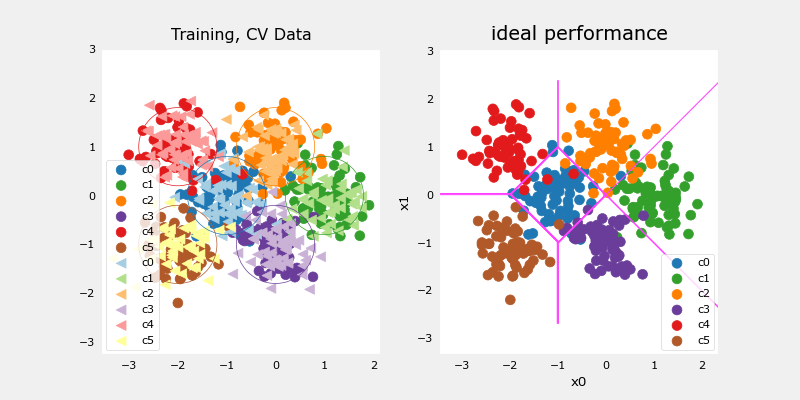

In [17]:
plt_train_eq_dist(X_train, y_train,classes, X_cv, y_cv, centers, std)

在上方，你可以看到左边的数据。有六个通过颜色标识的聚类。训练点（圆点）和交叉验证点（三角形）都显示出来了。有趣的点是那些落在模糊位置的点，在这些位置上，任意一个聚类都可能将它们视为成员。你期望神经网络模型怎么做呢？过拟合的例子会是什么？欠拟合呢？   
右边是一个 “理想” 模型的例子，或者说是一个知道数据来源后可能构建出的模型。这些线代表 “等距” 边界，中心点之间的距离相等。值得注意的是，这个模型会将大约8% 的总数据集 “误分类”。 

<a name="4.2"></a>
### 4.2 通过计算分类错误评估分类模型
此处用于分类模型的评估函数很简单，就是错误预测的比例：  
$$ J_{cv} =\frac{1}{m}\sum_{i=0}^{m-1} 
\begin{cases}
    1, & \text{if $\hat{y}^{(i)} \neq y^{(i)}$}\\
    0, & \text{otherwise}
\end{cases}
$$

<a name="ex02"></a>
### 练习2
在下方，完成用于计算分类错误的程序。请注意，在本实验中，目标值是类别的索引，并非[独热编码](https://en.wikipedia.org/wiki/One-hot)。 

In [18]:
# UNQ_C2
# GRADED CELL: eval_cat_err
def eval_cat_err(y, yhat):
    """ 
    Calculate the categorization error
    Args:
      y    : (ndarray  Shape (m,) or (m,1))  target value of each example
      yhat : (ndarray  Shape (m,) or (m,1))  predicted value of each example
    Returns:|
      cerr: (scalar)             
    """
    m = len(y)
    incorrect = 0
    for i in range(m):
    ### START CODE HERE ### 
        if yhat[i] != y[i]:
            incorrect += 1
    cerr = incorrect/m
    ### END CODE HERE ### 
    
    return(cerr)

In [19]:
y_hat = np.array([1, 2, 0])
y_tmp = np.array([1, 2, 3])
print(f"categorization error {np.squeeze(eval_cat_err(y_hat, y_tmp)):0.3f}, expected:0.333" )
y_hat = np.array([[1], [2], [0], [3]])
y_tmp = np.array([[1], [2], [1], [3]])
print(f"categorization error {np.squeeze(eval_cat_err(y_hat, y_tmp)):0.3f}, expected:0.250" )

# BEGIN UNIT TEST  
test_eval_cat_err(eval_cat_err)
# END UNIT TEST
# BEGIN UNIT TEST  
test_eval_cat_err(eval_cat_err)
# END UNIT TEST

categorization error 0.333, expected:0.333
categorization error 0.250, expected:0.250
 All tests passed.
 All tests passed.


<details>
  <summary><font size="3" color="darkgreen"><b>Click for hints</b></font></summary>
    
```python
def eval_cat_err(y, yhat):
    """ 
    Calculate the categorization error
    Args:
      y    : (ndarray  Shape (m,) or (m,1))  target value of each example
      yhat : (ndarray  Shape (m,) or (m,1))  predicted value of each example
    Returns:|
      cerr: (scalar)             
    """
    m = len(y)
    incorrect = 0
    for i in range(m):
        if yhat[i] != y[i]:    # @REPLACE
            incorrect += 1     # @REPLACE
    cerr = incorrect/m         # @REPLACE
    return(cerr)                                    
``` 

<a name="5"></a>
## 5 - 模型复杂度
在下面，你将构建两个模型。一个复杂模型和一个简单模型。你将评估这些模型，以确定它们是否可能过拟合或欠拟合。

### 5.1 复杂模型
<a name="ex03"></a>
### 练习3
在下面，构建一个三层模型：
* 具有120个单元的密集层，使用relu激活函数
* 具有40个单元的密集层，使用relu激活函数
* 具有6个单元且使用线性激活函数（非softmax）的密集层   
使用以下方式编译：
* 损失函数使用`SparseCategoricalCrossentropy`，记得使用`from_logits=True`
* 学习率为0.01的Adam优化器。

In [20]:
# UNQ_C3
# GRADED CELL: model
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)

tf.random.set_seed(1234)
model = Sequential(
    [
        ### START CODE HERE ###
        Dense(units=120, activation="relu"),
        Dense(units=40, activation="relu"),
        Dense(units=6, activation="linear"),
        ### END CODE HERE ### 

    ], name="Complex"
)
model.compile(
    ### START CODE HERE ### 
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),          
    optimizer=tf.keras.optimizers.Adam(0.01),  
    ### END CODE HERE ### 
)

In [21]:
# BEGIN UNIT TEST
model.fit(
    X_train, y_train,
    epochs=1000,
    verbose=0
)
# END UNIT TEST

In [22]:
# BEGIN UNIT TEST
model.summary()

model_test(model, classes, X_train.shape[1]) 
# END UNIT TEST

Model: "Complex"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 120)            │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │         4,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           246 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,340 (127.66 KB)

 Trainable params: 5,446 (42.55 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,894 (85.11 KB)

All tests passed!


<details>
  <summary><font size="3" color="darkgreen"><b>Click for hints</b></font></summary>
    
Summary should match this (layer instance names may increment )

```
Model: "Complex"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
=================================================================
L1 (Dense)                   (None, 120)               360       
_________________________________________________________________
L2 (Dense)                   (None, 40)                4840      
_________________________________________________________________
L3 (Dense)                   (None, 6)                 246       
=================================================================
Total params: 5,446
Trainable params: 5,446
Non-trainable params: 0
_________________________________________________________________
```

  <details>
  <summary><font size="3" color="darkgreen"><b>Click for more hints</b></font></summary>
  
```python
tf.random.set_seed(1234)
model = Sequential(
    [
        Dense(120, activation = 'relu', name = "L1"),      
        Dense(40, activation = 'relu', name = "L2"),         
        Dense(classes, activation = 'linear', name = "L3")  
    ], name="Complex"
)
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),          
    optimizer=tf.keras.optimizers.Adam(0.01),   
)

model.fit(
    X_train,y_train,
    epochs=1000
)                                  
``` 

1082/1082 ━━━━━━━━━━━━━━━━━━━━ 0s 280us/step
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 0s 260us/step


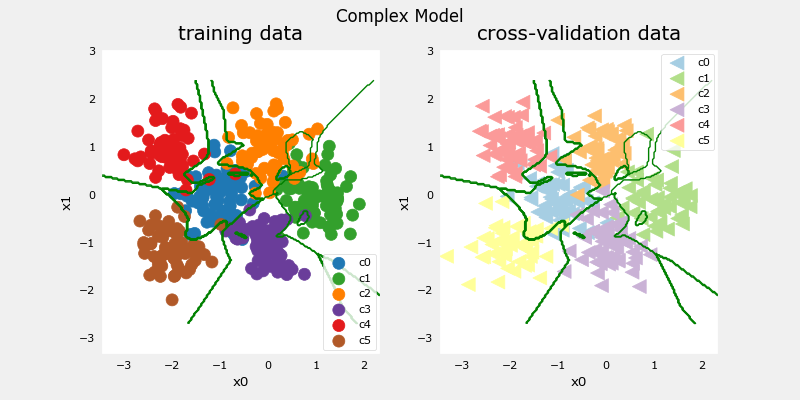

In [23]:
#make a model for plotting routines to call
model_predict = lambda Xl: np.argmax(tf.nn.softmax(model.predict(Xl)).numpy(),axis=1)
plt_nn(model_predict,X_train,y_train, classes, X_cv, y_cv, suptitle="Complex Model")

该模型非常努力地捕捉每个类别的异常值。结果，它对一些交叉验证数据进行了错误分类。让我们计算分类误差。

In [24]:
training_cerr_complex = eval_cat_err(y_train, model_predict(X_train))
cv_cerr_complex = eval_cat_err(y_cv, model_predict(X_cv))
print(f"categorization error, training, complex model: {training_cerr_complex:0.3f}")
print(f"categorization error, cv,       complex model: {cv_cerr_complex:0.3f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 904us/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
categorization error, training, complex model: 0.013
categorization error, cv,       complex model: 0.106


<a name="5.1"></a>
### 5.1 简单模型
现在，让我们尝试一个简单的模型

<a name="ex04"></a>
### 练习4
在下面构建一个两层模型：
* 具有6个单元的密集层，使用relu激活函数
* 具有6个单元且使用线性激活函数的密集层。    
使用以下方式编译：
* 损失函数使用`SparseCategoricalCrossentropy`，记得使用`from_logits=True`
* 学习率为0.01的Adam优化器。

In [25]:
# UNQ_C4
# GRADED CELL: model_s

tf.random.set_seed(1234)
model_s = Sequential(
    [
        ### START CODE HERE ### 
        Dense(6, activation = 'relu', name="L1"),            
        Dense(classes, activation = 'linear', name="L2")     
        ### END CODE HERE ### 
    ], name = "Simple"
)
model_s.compile(
    ### START CODE HERE ### 
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),     
    optimizer=tf.keras.optimizers.Adam(0.01),     
    ### START CODE HERE ### 
)


In [26]:
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)

# BEGIN UNIT TEST
model_s.fit(
    X_train,y_train,
    epochs=1000,
    verbose=0
)
# END UNIT TEST

In [27]:
# BEGIN UNIT TEST
model_s.summary()

model_s_test(model_s, classes, X_train.shape[1])
# END UNIT TEST

Model: "Simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 6)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 6)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182 (1.42 KB)

 Trainable params: 60 (480.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 122 (976.00 B)

All tests passed!


<details>
  <summary><font size="3" color="darkgreen"><b>Click for hints</b></font></summary>
    
Summary should match this (layer instance names may increment )

```
Model: "Simple"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
=================================================================
L1 (Dense)                   (None, 6)                 18        
_________________________________________________________________
L2 (Dense)                   (None, 6)                 42        
=================================================================
Total params: 60
Trainable params: 60
Non-trainable params: 0
_________________________________________________________________
```
  <details>
  <summary><font size="3" color="darkgreen"><b>Click for more hints</b></font></summary>
  
```python
tf.random.set_seed(1234)
model_s = Sequential(
    [
        Dense(6, activation = 'relu', name="L1"),            # @REPLACE
        Dense(classes, activation = 'linear', name="L2")     # @REPLACE
    ], name = "Simple"
)
model_s.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),     # @REPLACE
    optimizer=tf.keras.optimizers.Adam(0.01),     # @REPLACE
)

model_s.fit(
    X_train,y_train,
    epochs=1000
)                                   
``` 

1082/1082 ━━━━━━━━━━━━━━━━━━━━ 0s 248us/step
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 0s 232us/step


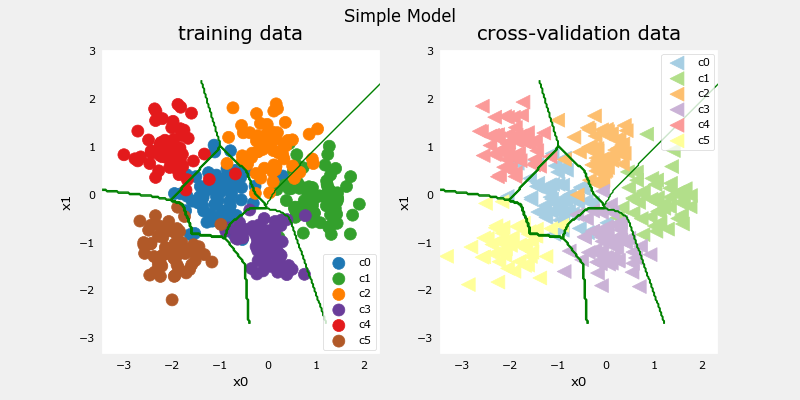

In [28]:
#make a model for plotting routines to call
model_predict_s = lambda Xl: np.argmax(tf.nn.softmax(model_s.predict(Xl)).numpy(),axis=1)
plt_nn(model_predict_s,X_train,y_train, classes, X_cv, y_cv, suptitle="Simple Model")

这个简单的模型表现相当不错。我们来计算一下分类误差。

In [29]:
training_cerr_simple = eval_cat_err(y_train, model_predict_s(X_train))
cv_cerr_simple = eval_cat_err(y_cv, model_predict_s(X_cv))
print(f"categorization error, training, simple model, {training_cerr_simple:0.3f}, complex model: {training_cerr_complex:0.3f}" )
print(f"categorization error, cv,       simple model, {cv_cerr_simple:0.3f}, complex model: {cv_cerr_complex:0.3f}" )

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
categorization error, training, simple model, 0.065, complex model: 0.013
categorization error, cv,       simple model, 0.078, complex model: 0.106


我们的简单模型在训练数据上的分类误差略高，但在交叉验证数据上的表现比更复杂的模型更好。

<a name="6"></a>
## 6 - 正则化
与多项式回归的情况一样，可以应用正则化来缓和更复杂模型的影响。下面我们来试试。

<a name="ex05"></a>
### 练习5
重构你的复杂模型，但这次加入正则化。   
下面，构建一个三层模型：   
* 具有120个单元的全连接层，激活函数为relu，`kernel_regularizer=tf.keras.regularizers.l2(0.1)`
* 具有40个单元的全连接层，激活函数为relu，`kernel_regularizer=tf.keras.regularizers.l2(0.1)`
* 具有6个单元且激活函数为线性的全连接层。
使用以下方式编译：   
* 损失函数为`SparseCategoricalCrossentropy`，记得使用`from_logits=True`
* 学习率为0.01的Adam优化器。

In [30]:
# UNQ_C5
# GRADED CELL: model_r

tf.random.set_seed(1234)
model_r = Sequential(
    [
        ### START CODE HERE ### 
        Dense(120, activation = 'relu', kernel_regularizer=tf.keras.regularizers.l2(0.1), name="L1"), 
        Dense(40, activation = 'relu', kernel_regularizer=tf.keras.regularizers.l2(0.1), name="L2"),  
        Dense(classes, activation = 'linear', name="L3")
        ### START CODE HERE ### 
    ], name= None
)
model_r.compile(
    ### START CODE HERE ### 
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), 
    optimizer=tf.keras.optimizers.Adam(0.01), 
    ### START CODE HERE ### 
)


In [31]:
# BEGIN UNIT TEST
model_r.fit(
    X_train, y_train,
    epochs=1000,
    verbose=0
)
# END UNIT TEST

In [32]:
# BEGIN UNIT TEST
model_r.summary()

model_r_test(model_r, classes, X_train.shape[1]) 
# END UNIT TEST

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 120)            │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 40)             │         4,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3 (Dense)                      │ (None, 6)              │           246 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,340 (127.66 KB)

 Trainable params: 5,446 (42.55 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,894 (85.11 KB)

ddd
All tests passed!


<details>
  <summary><font size="3" color="darkgreen"><b>Click for hints</b></font></summary>
    
Summary should match this (layer instance names may increment )

```
Model: "ComplexRegularized"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
=================================================================
L1 (Dense)                   (None, 120)               360       
_________________________________________________________________
L2 (Dense)                   (None, 40)                4840      
_________________________________________________________________
L3 (Dense)                   (None, 6)                 246       
=================================================================
Total params: 5,446
Trainable params: 5,446
Non-trainable params: 0
_________________________________________________________________
```
  <details>
  <summary><font size="3" color="darkgreen"><b>Click for more hints</b></font></summary>
  
```python
tf.random.set_seed(1234)
model_r = Sequential(
    [
        Dense(120, activation = 'relu', kernel_regularizer=tf.keras.regularizers.l2(0.1), name="L1"), 
        Dense(40, activation = 'relu', kernel_regularizer=tf.keras.regularizers.l2(0.1), name="L2"),  
        Dense(classes, activation = 'linear', name="L3")  
    ], name="ComplexRegularized"
)
model_r.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), 
    optimizer=tf.keras.optimizers.Adam(0.01),                             
)

model_r.fit(
    X_train,y_train,
    epochs=1000
)                                   
``` 

1082/1082 ━━━━━━━━━━━━━━━━━━━━ 0s 290us/step
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 0s 263us/step


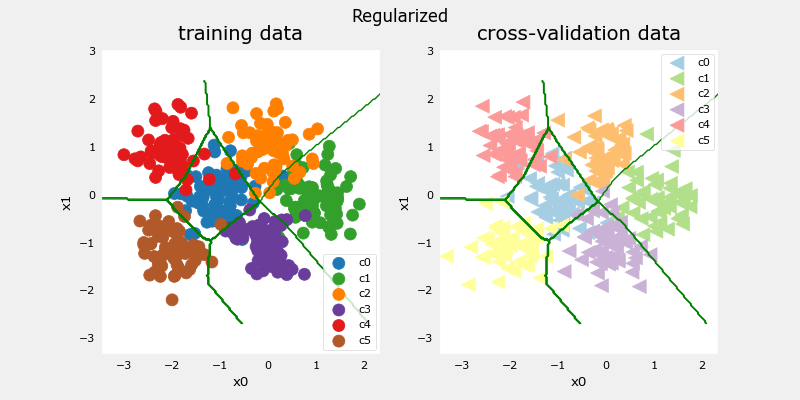

In [33]:
#make a model for plotting routines to call
model_predict_r = lambda Xl: np.argmax(tf.nn.softmax(model_r.predict(Xl)).numpy(),axis=1)
 
plt_nn(model_predict_r, X_train,y_train, classes, X_cv, y_cv, suptitle="Regularized")

结果看起来与“理想”模型非常相似。我们来检查一下分类错误。

In [34]:
training_cerr_reg = eval_cat_err(y_train, model_predict_r(X_train))
cv_cerr_reg = eval_cat_err(y_cv, model_predict_r(X_cv))
test_cerr_reg = eval_cat_err(y_test, model_predict_r(X_test))
print(f"categorization error, training, regularized: {training_cerr_reg:0.3f}, simple model, {training_cerr_simple:0.3f}, complex model: {training_cerr_complex:0.3f}" )
print(f"categorization error, cv,       regularized: {cv_cerr_reg:0.3f}, simple model, {cv_cerr_simple:0.3f}, complex model: {cv_cerr_complex:0.3f}" )

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
categorization error, training, regularized: 0.077, simple model, 0.065, complex model: 0.013
categorization error, cv,       regularized: 0.075, simple model, 0.078, complex model: 0.106


简单模型在训练集上比正则化模型表现稍好，但在交叉验证集中表现较差。

<a name="7"></a>
## 7 - 迭代寻找最优正则化值
如同你在线性回归中所做的那样，你可以尝试许多正则化值。   
这段代码运行需要几分钟时间。如果你有时间，可以运行它并查看结果。如果没有时间，你已经完成了作业的评分部分！

In [35]:
tf.random.set_seed(1234)
lambdas = [0.0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3]
models=[None] * len(lambdas)
for i in range(len(lambdas)):
    lambda_ = lambdas[i]
    models[i] =  Sequential(
        [
            Dense(120, activation = 'relu', kernel_regularizer=tf.keras.regularizers.l2(lambda_)),
            Dense(40, activation = 'relu', kernel_regularizer=tf.keras.regularizers.l2(lambda_)),
            Dense(classes, activation = 'linear')
        ]
    )
    models[i].compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        optimizer=tf.keras.optimizers.Adam(0.01),
    )

    models[i].fit(
        X_train,y_train,
        epochs=1000,
        verbose=0
    )
    print(f"Finished lambda = {lambda_}")


Finished lambda = 0.0
Finished lambda = 0.001
Finished lambda = 0.01
Finished lambda = 0.05
Finished lambda = 0.1
Finished lambda = 0.2
Finished lambda = 0.3


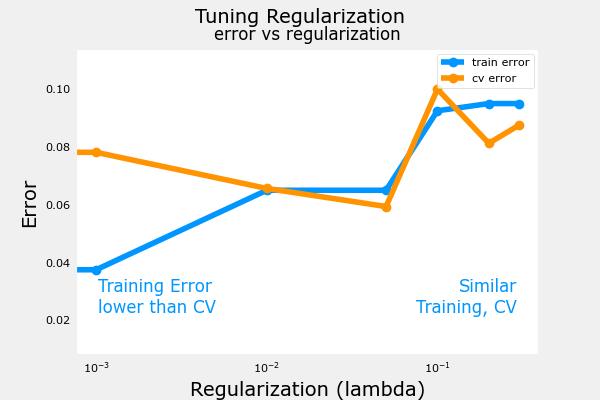

In [36]:
plot_iterate(lambdas, models, X_train, y_train, X_cv, y_cv)

随着正则化程度的增加，模型在训练数据集和交叉验证数据集上的性能趋于一致。对于这个数据集和模型，λ > 0.01似乎是一个合理的选择。

<a name="7.1"></a>
### 7.1 测试
让我们在测试集上尝试优化后的模型，并将它们与“理想”性能进行比较。

1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 249us/step
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 267us/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


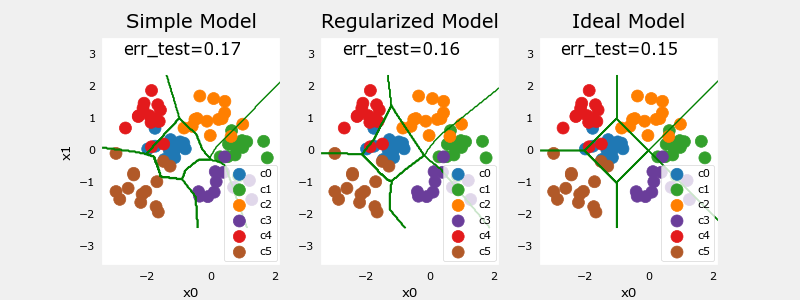

In [37]:
plt_compare(X_test,y_test, classes, model_predict_s, model_predict_r, centers)

我们的测试集规模较小，似乎存在一些离群值，因此分类误差较高。不过，我们优化后的模型性能与理想性能相当。

## 恭喜！
你已经熟悉了评估机器学习模型时要使用的重要工具。具体而言：
* 将数据拆分为训练集和未训练集，可让你区分欠拟合和过拟合。
* 创建三个数据集，即训练集、交叉验证集和测试集，这使你能够：
    * 使用训练集训练参数 $W$、$B$。
    * 使用交叉验证集调整模型参数，如复杂度、正则化和示例数量。
    * 使用测试集评估“实际应用”中的性能。
* 比较训练集与交叉验证集的性能，有助于深入了解模型的过拟合（高方差）或欠拟合（高偏差）倾向。 